# Trabajo Práctico número 2

Integrantes
- Gaspar Acevedo Zain (acevedo.zain.gaspar@gmail.com)

## Carga de utilities

In [162]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from typing import Optional, Tuple
import supervision as sv
%matplotlib inline

In [163]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))

from utilities.image_quality import ImageQuality, QualityMeasure

In [164]:
video_path = '../../Material_TPs/TP2/focus_video.mov'

In [165]:
imageQuality = ImageQuality()

## Enunciado

***Objetivo***

Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: “focus_video.mov”.
1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain" y realizar tres experimentos:
    1. Medición sobre todo el frame.
    1. Medición sobre una ROI ubicada en el centro del frame.  Area de la ROI = 5 o 10% del area total del frame.
    1. Opcional:
        1. Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 3x3, 7x5, etc ... (al menos 3) 
    - Para cada experimento se debe presentar :
        - Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto el punto de máximo enfoque.
2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure 
operators in shapefrom focus.
    -   El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera automática.

***Puntos extra***: Aplicar unsharp masking para expandir la zona de enfoque y recalcular la métrica.

## Funciones generales

In [166]:
def obtener_métricas_de_video(path:str, measure: QualityMeasure = QualityMeasure.IMAGE_SHARPNESS_MEASURE,
                              roiPercentage:float=1.0, unsharpMasking:Optional[Tuple[float, float]] = None
                              ) -> Tuple[pd.DataFrame, int, float, cv.typing.MatLike]:
    """
    Lee un video y obtiene calcula una métrica de enfoque en cada frame.

    Args:
        path (str): Path al video.
        measure (QualityMeasure): algoritmo a aplicar para calcular la métrica de calidad.
            Default: IMAGE_SHARPNESS_MEASURE (ver paper `Image Sharpness Measure for Blurred Images
            in Frequency Domain`).
        roiPercentage (float): Porcentage de área de interés (ROI), ubicada en el centro del frame.
            Default: 1.0 (no aplica ROI).
    Returns:
        Tupla:
            pd.DataFrame con columnas que representan los frames y sus respectivas métricas.
            int: Frame en donde se obtuvo el valor de máximo enfoque.
            float: Valor del máximo enfoque obtenido.
            cv.typing.MatLike: Frame con mejor métrica de enfoque.
    Raises:
        IOError: si no se puede abrir el video.
    """
    captura_video = cv.VideoCapture(path)

    imageQuality = ImageQuality()
    results = pd.DataFrame(columns=["Frame", measure.name])

    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
        raise IOError(f"Error al abrir el archivo de video")
    else:
        frame_numero = 0
        best_quality_value = -np.inf
        best_frame = None
        best_gray_frame = None
        while True:
            ret, frame = captura_video.read()
            if not ret:
                break
            
            frame - cv.cvtColor(frame, cv.COLOR_BGR2RGB)
            gray_frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

            iqm = imageQuality.imageQualityMeasure(image=gray_frame,
                                                   unsharpMasking=unsharpMasking,
                                                   roiPercentage=roiPercentage,
                                                   measure=measure)
            results.loc[len(results)] = [frame_numero, iqm]
            frame_numero = frame_numero + 1

            # Definimos cual es la mejor métrica y el mejor frame
            if iqm > best_quality_value:
                best_quality_value = iqm
                best_frame = frame
                best_gray_frame = gray_frame

    captura_video.release()
    
    max_enfoque_idx = results[measure.name].idxmax()

    max_enfoque_value = results.loc[max_enfoque_idx, measure.name]
    max_enfoque_frame = results.loc[max_enfoque_idx, "Frame"]

    return results, max_enfoque_frame, max_enfoque_value, best_frame, best_gray_frame

In [167]:
def graficar_metricas_por_frames(data: pd.DataFrame, x: int, y: float, title: str):
    """
    Grafica un dataframe que contiene números de frames y sus respectivas métricas de enfoque.

    Args:
        data (pd.DataFrame): DataFrame con los datos a graficar.
        x (int): Frame con el valor de máximo enfoque.
        y (float): Métrica de máximo enfoque.
        title (str): Título
    """
    plt.scatter(data.iloc[:,0], data.iloc[:,1])
    plt.scatter(x, y, c="red", marker="D", label=f"{(int(x), float(np.round(y, 4)))}")
    plt.title(title)
    plt.xlabel(data.columns[0])
    plt.ylabel(data.columns[1])
    plt.legend(loc='upper left', title="Máximo Enfoque", ncol=1, fontsize='small', frameon=True, shadow=True)

In [168]:
def graficar_imagenes_utilizadas(image: cv.typing.MatLike, image_grayscale: cv.typing.MatLike, roiPercentage: float, unsharpMasking: Tuple[float, float]):
    """
    Grafica las imágenes utilizadas en un experimento.

    Args:
        image (cv.typing.MatLike): imágen que obtuvo la mejor métrica de enfoque en un experimento, en RGB.
        image_grayscale (cv.typing.MatLike): imágen que obtuvo la mejor métrica de enfoque en un experimento, en grayscale.
        roiPercentage (float): porcentaje de ROI utilizado. Si ess 100%, no se aplica ROI.
        unsharpMasking (Tuple[float, float]): valores utilizados en unsharp masking. Corresponden a los valores de
            sigma y strength.
    """
    unsharped = imageQuality.__unsharpMasking__(image=image_grayscale, sigma=unsharpMasking[0], strength=unsharpMasking[1])
    if roiPercentage == 1.0:
        roiImage = unsharped
    else:
        roiImage = imageQuality.__getROIFromImage__(image=unsharped, percentage=roiPercentage)

    sv.plot_images_grid(
        images=[image, image_grayscale, unsharped, roiImage],
        titles=['Original', 'Grayscale', f'Unsharped (sigma={unsharpMasking[0]}; strength={unsharpMasking[1]})', f'ROI {roiPercentage*100}%'],
        grid_size=(2, 2)
    )

## Punto 1

A continuación se realizarán tres experimentos en donde se analiza el video de `focus_video.mov` frame a frame con el fin de obtener la métrica de nitidez o "Sharpness" definida en el paper `Image Sharpness Measure for Blurred Images in Frequency Domain`.

***Preliminares - Representación frame a frame de la métrica***

El video a analizar se caracteriza por estar desenfocado al inicio y al final, mientras que el resto del video la cámara está enfocada. De esta manera, podemos anticipar que la representación gráfica frame a frame de esta métrica (y otras métricas similares) se asemejará a una curva similar a la Normal, ya que:
1. Al principio el video está desenfocado, es decir, habrá un valor bajo de métrica.
1. Luego se va enfocando poco a poco, es decir, la métrica irá aumentando hasta alcanzar un punto de *máximo enfoque*. 
1. Finalmente vuelve a desenfocarse poco a poco, es decir, la métrica irá disminuyendo hasta el final del video (último frame).

***Algoritmo para cálculo de métrica***

En cuanto al algoritmo propuesto por el paper `Image Sharpness Measure for Blurred Images in Frequency Domain`, está implementando en el método `imageSharpnessMeasure` de la clase `ImageQuality` (ver [utilities/image_quality.py](../utilities/image_quality.py)) y se define como:

*Input*: una imagen $I$.

- *Paso 1*: Computar $F$ o la representación de la transformada de Fourier de la imagen $I$.
- *Paso 2*: Encontrar $Fc$ que se obtiene desplazando el origen de $F$ al centro.
- *Paso 3*: Calcular $AF = abs (Fc)$, donde $AF$ es el valor absoluto de la transformada de Fourier centrada de la imagen $I$.
- *Paso 4*: Calcular $M = max (AF)$, donde $M$ es el valor donde $M$ es el valor máximo del componente de frecuencia en $F$.
- *Paso 5*: Calcular $TH$, que representa el total de pixeles de $F$ donde el valor del pixel es mayor a $thres = M/1000$.
- *Paso 6*: Calcular la métrica de calidad de Imagen (FM) a partir de la ecuación $TH/(MxN)$.

*Output*: métrica de calidad.

***Definición de experimentos***

En cuanto a los experimentos, estos se caracterizan por lo siguiente:

1. Se procesará el video `focus_video.mov` frame a frame.
1. Se convertirá el frame *BGR* en *escala de grises*. Esto se debe a lo siguiente:
    1. El método para procesar video mediante *OpenCV* (cv.VideoCapture) devuelve los frames en *BGR* (mas info [aquí](https://docs.opencv.org/4.x/dd/d43/tutorial_py_video_display.html)).
    1. El algoritmo implementa la transformada de *Fourier* y la implementación de *Numpy* (`np.fft.fft2`) requiere la imagen en escala de grises (mas info [aquí](https://docs.opencv.org/4.x/de/dbc/tutorial_py_fourier_transform.html)).
1. Se Aplicará *unsharp masking* para mejorar la nitidez de la imagen (mas info [aquí](https://www.opencvhelp.org/tutorials/image-processing/how-to-sharpen-image/)).
    1. `sigmaX` de $1.0$: corresponde al desvío estandar del kernel gaussiano en *X* y determinará el tamaño del kernel a utilizar (mas info [aquí](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gae8bdcd9154ed5ca3cbc1766d960f45c1)).
    1. `sigmaY`: se utilizará el mismo valor que `sigmaX`, tal como especifica la documentación de [GaussianBlur()](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gae8bdcd9154ed5ca3cbc1766d960f45c1) de *OpenCV*.
    1. `strength`: se configurará con un valor de $3.0$.
1. En algunos experimentos, se calculará un *área de interés* o *ROI* de la imagen a partir de su centro, con un área correspondiente al $5\%$ o $10\%$ del área total del frame.
1. Se obtendrá la métrica definida en el paper sobre una región del frame.
1. Se graficará la evolución de la métrica frame a frame.

| Métrica | unsharp masking - `sigmaX` | unsharp masking - `weight` | ROI% |
| --- | --- | --- | --- |
| `Image Sharpness` | $1.0$ | $3.0$ | No aplica (o ROI de 100%) |
| `Image Sharpness` | $1.0$ | $3.0$ | ROI $5\%$ |
| `Image Sharpness` | $1.0$ | $3.0$ | ROI $10\%$ |

### Definimos el unsharp masking a utilizar en todos los experimentos

In [169]:
unsharpMasking = (1.0, 3.0)

### Experimento 01 - Métrica: Image Sharpness Measure - Con Unsharp Masking - Sin ROI

***Descripción del experimento 01***

A continuación se procesa el video utilizando la métrica definida en el paper `Image Sharpness Measure for Blurred Images in Frequency Domain`, trabajando con:
- *unsharp Masking* de `sigmaX` = $1.0$ y `strength` de $3.0$.
- Sin ROI.

***Resultados***

- El gráfico de la evolución de la métrica coincide con lo planteado al inicio de este ejercicio, ya que se ve como en los primeros frames el valor es bajo, luego se va incrementando hasta alcanzar un punto de *máximo enfoque*, y luego comienza a decrecer hasta que finaliza el video.

- El frame con mayor métrica de enfoque fue el número $109$, con un valor de métrica de $0.0192$.
- El tiempo de ejecución fue de $6.6$ segundos.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $01$ | `Image Sharpness` | $1.0$ | $3.0$ | - | $109$ | $0.0192$ | $6.6$ segundos. |

In [170]:
ims_roi_100_df, ims_roi_100_max_frame, ims_roi_100_max_measure, ms_roi_100_frame, ms_roi_100_gray_frame = obtener_métricas_de_video(path=video_path, roiPercentage=1.0, unsharpMasking=unsharpMasking, measure=QualityMeasure.IMAGE_SHARPNESS_MEASURE)

A continuación grafica la evolución de la métrica de enfoque frame a frame. En rojo se resalta el punto de máximo enfoque.

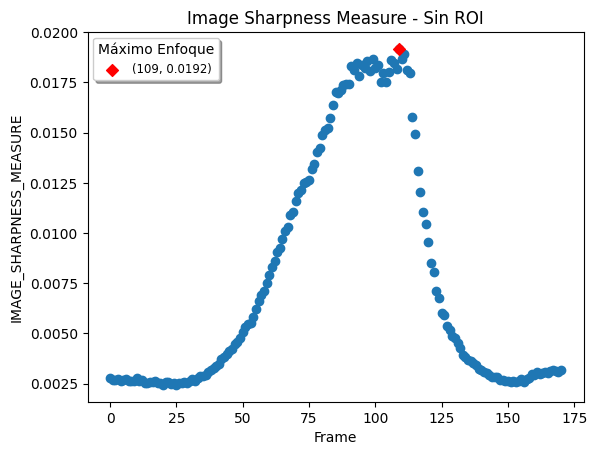

In [171]:
graficar_metricas_por_frames(ims_roi_100_df, x=ims_roi_100_max_frame, y=ims_roi_100_max_measure, title="Image Sharpness Measure - Sin ROI")

A continuación se muestra el frame con valor de máximo enfoque:

- Versión original
- Versión escala de grises
- Versión con *unsharped masking*
- Versión con ROI 100% (en este caso, el ROI no se aplica)

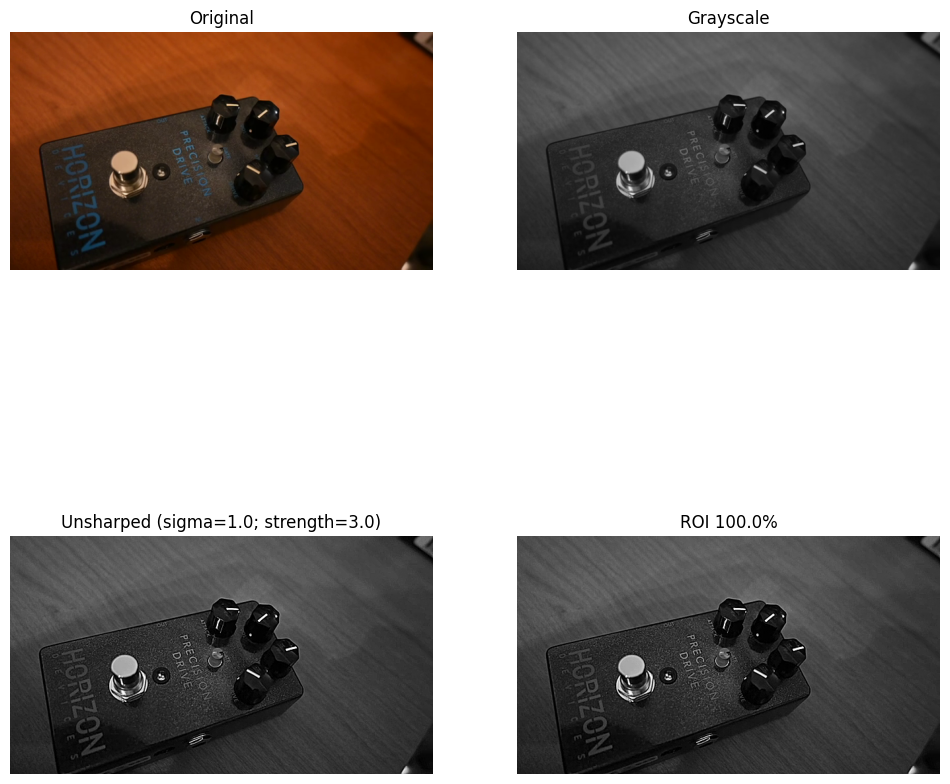

In [172]:
graficar_imagenes_utilizadas(ms_roi_100_frame, ms_roi_100_gray_frame, roiPercentage=1.0, unsharpMasking=unsharpMasking)

### Experimento 02 - Métrica: Image Sharpness Measure - Con Unsharp Masking - ROI 5%

***Descripción del experimento 02***

A continuación se procesa el video utilizando la métrica definida en el paper `Image Sharpness Measure for Blurred Images in Frequency Domain`, trabajando con:
- *unsharp Masking* de `sigmaX` = $1.0$ y `strength` de $3.0$.
- Con ROI de $5\%$.

***Resultados***

- En este caso el gráfico tiene una distribución similar a la esperada, pero con puntos dispersos en comparación a los resutlados del punto anterior
- El frame con mayor métrica de enfoque fue el número $87$, con un valor de métrica de $0.5295$.
- El tiempo de ejecución fue de $0.7$ segundos.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $01$ | `Image Sharpness` | $1.0$ | $3.0$ | - | $109$ | $0.0192$ | $6.6$ segundos. |
| $02$ | `Image Sharpness` | $1.0$ | $3.0$ | $5\%$ | $87$ | $0.5295$ | $0.7$ segundos. |

In [189]:
ims_roi_5_df, ims_roi_5_max_frame, ims_roi_5_max_measure, ms_roi_5_frame, ms_roi_5_gray_frame = obtener_métricas_de_video(path=video_path, roiPercentage=0.05, unsharpMasking=unsharpMasking, measure=QualityMeasure.IMAGE_SHARPNESS_MEASURE)

A continuación grafica la evolución de la métrica de enfoque frame a frame. En rojo se resalta el punto de máximo enfoque.

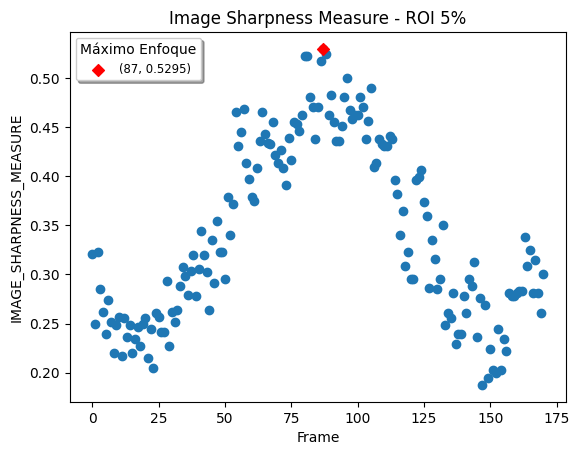

In [174]:
graficar_metricas_por_frames(ims_roi_5_df, x=ims_roi_5_max_frame, y=ims_roi_5_max_measure, title="Image Sharpness Measure - ROI 5%")

A continuación se muestra el frame con valor de máximo enfoque:

- Versión original
- Versión escala de grises
- Versión con *unsharped masking*
- Versión con ROI de $5\%$

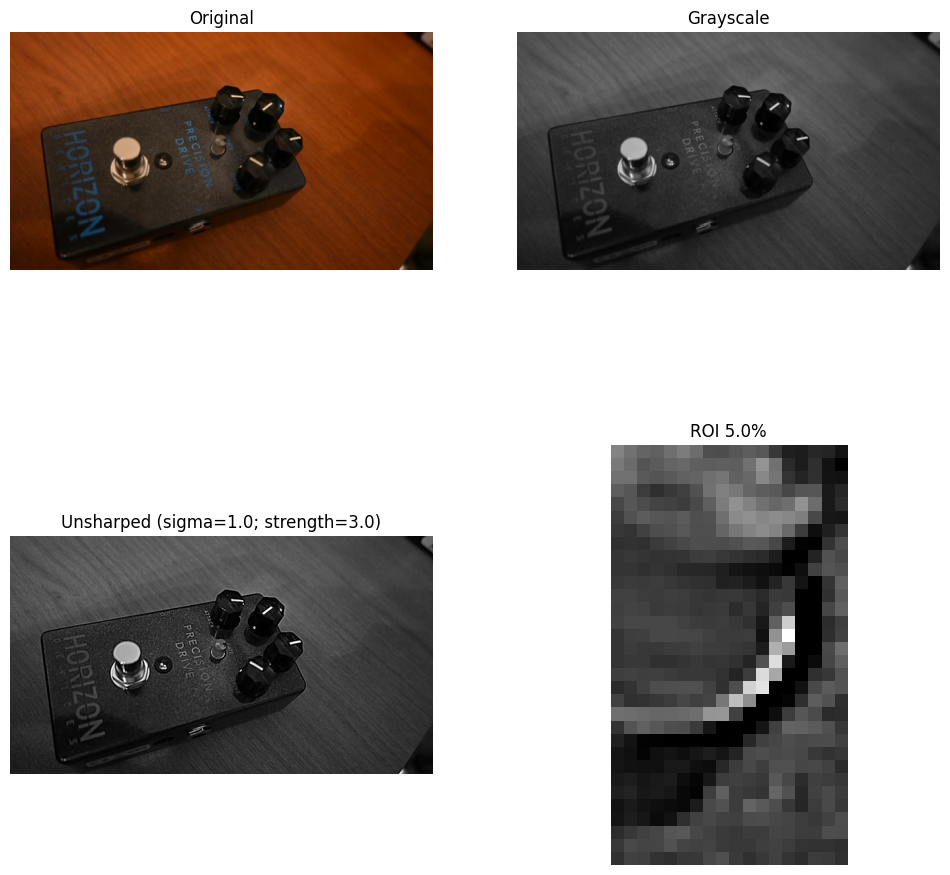

In [175]:
graficar_imagenes_utilizadas(ms_roi_5_frame, ms_roi_5_gray_frame, roiPercentage=0.05, unsharpMasking=unsharpMasking)

La siguiente imagen corresponde al ROI utilizado sobre el frame que obtuvo la mejor métrica de enfoque.

### Experimento 03 - Métrica: Image Sharpness Measure - ROI 10%

***Descripción del experimento 03***

A continuación se procesa el video utilizando la métrica definida en el paper `Image Sharpness Measure for Blurred Images in Frequency Domain`, trabajando con:
- *unsharp Masking* de `sigmaX` = $1.0$ y `strength` de $3.0$.
- Con ROI de $10\%$.

***Resultados***

- En este caso el gráfico tiene una distribución similar a la esperada.
- El frame con mayor métrica de enfoque fue el número $107$, con un valor de métrica de $0.4518$.
- El tiempo de ejecución fue de $0.7$ segundos.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $01$ | `Image Sharpness` | $1.0$ | $3.0$ | - | $109$ | $0.0192$ | $6.6$ segundos. |
| $02$ | `Image Sharpness` | $1.0$ | $3.0$ | $5\%$ | $87$ | $0.5295$ | $0.7$ segundos. |
| $02$ | `Image Sharpness` | $1.0$ | $3.0$ | $10\%$ | $107$ | $0.4518$ | $0.7$ segundos. |

In [176]:
ims_roi_10_df, ims_roi_10_max_frame, ims_roi_10_max_measure, ms_roi_10_frame, ms_roi_10_gray_frame = obtener_métricas_de_video(path=video_path, roiPercentage=0.1, unsharpMasking=unsharpMasking, measure=QualityMeasure.IMAGE_SHARPNESS_MEASURE)

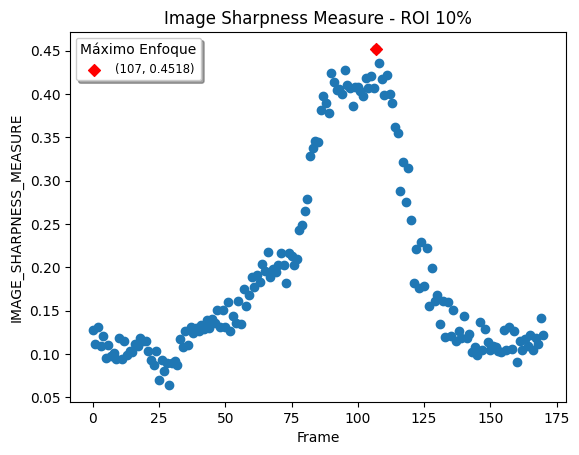

In [177]:
graficar_metricas_por_frames(ims_roi_10_df, x=ims_roi_10_max_frame, y=ims_roi_10_max_measure, title="Image Sharpness Measure - ROI 10%")

A continuación se muestra el frame con valor de máximo enfoque:

- Versión original
- Versión escala de grises
- Versión con *unsharped masking*
- Versión con ROI $10\%$

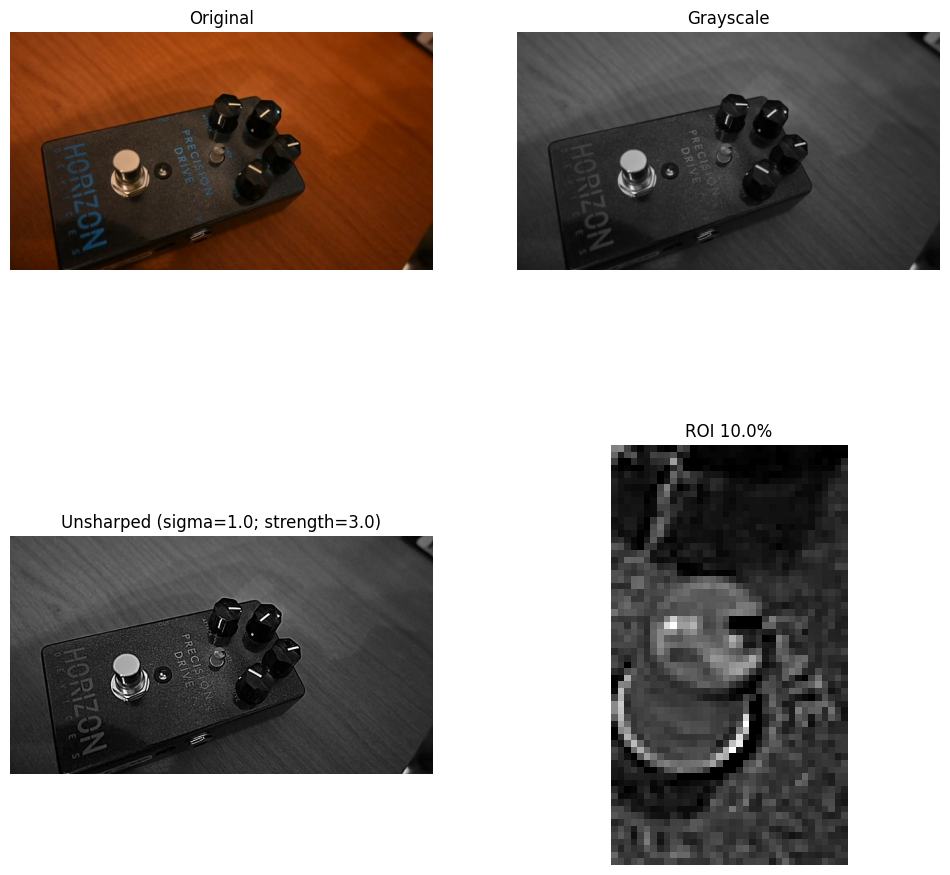

In [178]:
graficar_imagenes_utilizadas(ms_roi_10_frame, ms_roi_10_gray_frame, roiPercentage=0.1, unsharpMasking=unsharpMasking)

La siguiente imagen corresponde al ROI utilizado sobre el frame que obtuvo la mejor métrica de enfoque.

### Comparación de resultados de experimentos $01$, $02$ y $03$.

Estos son los resultados obtenidos al aplicar la técnica definida en el paper `Image Sharpness Measure for Blurred Images in Frequency Domain` en cada frame del video de análisis:

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $01$ | `Image Sharpness` | $1.0$ | $3.0$ | - | $109$ | $0.0192$ | $6.6$ segundos. |
| $02$ | `Image Sharpness` | $1.0$ | $3.0$ | $5\%$ | $87$ | $0.5295$ | $0.7$ segundos. |
| $02$ | `Image Sharpness` | $1.0$ | $3.0$ | $10\%$ | $107$ | $0.4518$ | $0.7$ segundos. |

En cuanto al punto de máximo enfoque, el experimento $01$ lo obtuvo en el frame $109$, el experimento $03$ en el frame $107$, pero el experimento $02$ lo obtuvo en el frame $87$, con una métrica superior a la de los demás.

***Gráfico comparativo***

A continuación se grafica la comparación de las evoluciones de la métrica de estudio frame a frame de los tres experimentos.

En este gráfico se observa que la métrica correspondiente al experimento $02$ (ROI del $5\%$) supera a las métricas de los otros dos experimentos, siendo la del experimento $01$ (sin *ROI*) la que tiene menor valor.

***Conclusión***

Se realizaron tres experimentos en un mismo video, calculando la métrica definida en el paper `Image Sharpness Measure for Blurred Images in Frequency Domain` frame a frame.

A cada uno de estos frames se les aplicó *escala de grises* y *unsharp masking* antes de calcular su métrica.

La única diferencia entre las configuraciones de los experimentos es el área de interés o ***ROI*** aplicado, teniendo al experimento $01$ sin ***ROI***, el experimento $02$ con $5\%$ y el experimento $03$ con $10\%$.

Al graficar las métricas frame a frame de cada experimento y compararlas entre sí, se observó que a *menor ROI*, *mayor es el valor de la métrica*.

También se nota que el tiempo de ejecución del algoritmo es menor cuando se aplica ***ROI*** que cuando NO se aplica.

Entonces, podemos concluir que, a la hora de implementar un algoritmo para detectar el ***desenfoque*** basado en la métrica definieda en el paper de `Image Sharpness Measure for Blurred Images in Frequency Domain` es conveniente aplicar sobre una región de interés pequeña ($5\%$ según este experimento) respecto del *centro de la imagen original*, ya que esto permite obtener *mejores métricas* y por lo tanto detectar el frame de ***máximo enfoque*** de una mejor manera, como así también permite realizarlo en un menor tiempo que aquel que requiere aplicar al algoritmo sobre el área total de la imagen (sin *ROI*).

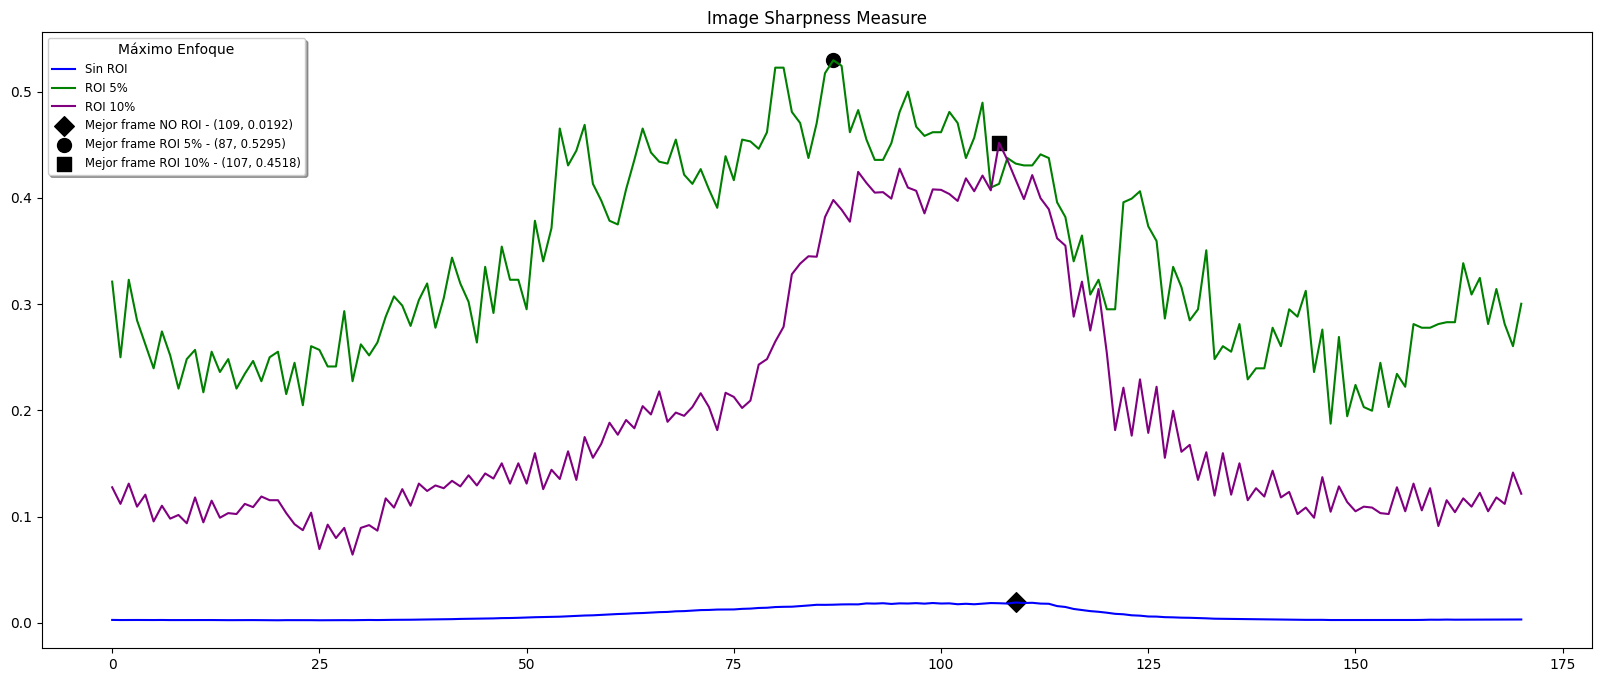

In [193]:

plt.figure(figsize=(20, 8))
plt.plot(ims_roi_100_df.iloc[:,0], ims_roi_100_df.iloc[:,1], c="blue", label=f"Sin ROI")
plt.plot(ims_roi_5_df.iloc[:,0], ims_roi_5_df.iloc[:,1], c="green", label=f"ROI 5%")
plt.plot(ims_roi_10_df.iloc[:,0], ims_roi_10_df.iloc[:,1], c="purple", label=f"ROI 10%")

plt.scatter(ims_roi_100_max_frame, ims_roi_100_max_measure, c="black", marker="D", s=100, label=f"Mejor frame NO ROI - {(int(ims_roi_100_max_frame), float(np.round(ims_roi_100_max_measure, 4)))}")
plt.scatter(ims_roi_5_max_frame, ims_roi_5_max_measure, c="black", marker="o", s=100, label=f"Mejor frame ROI 5% - {(int(ims_roi_5_max_frame), float(np.round(ims_roi_5_max_measure, 4)))}")
plt.scatter(ims_roi_10_max_frame, ims_roi_10_max_measure, c="black", marker="s", s=100, label=f"Mejor frame ROI 10% - {(int(ims_roi_10_max_frame), float(np.round(ims_roi_10_max_measure, 4)))}")

plt.title("Image Sharpness Measure")
plt.legend(loc='upper left', title="Máximo Enfoque", ncol=1, fontsize='small', frameon=True, shadow=True)

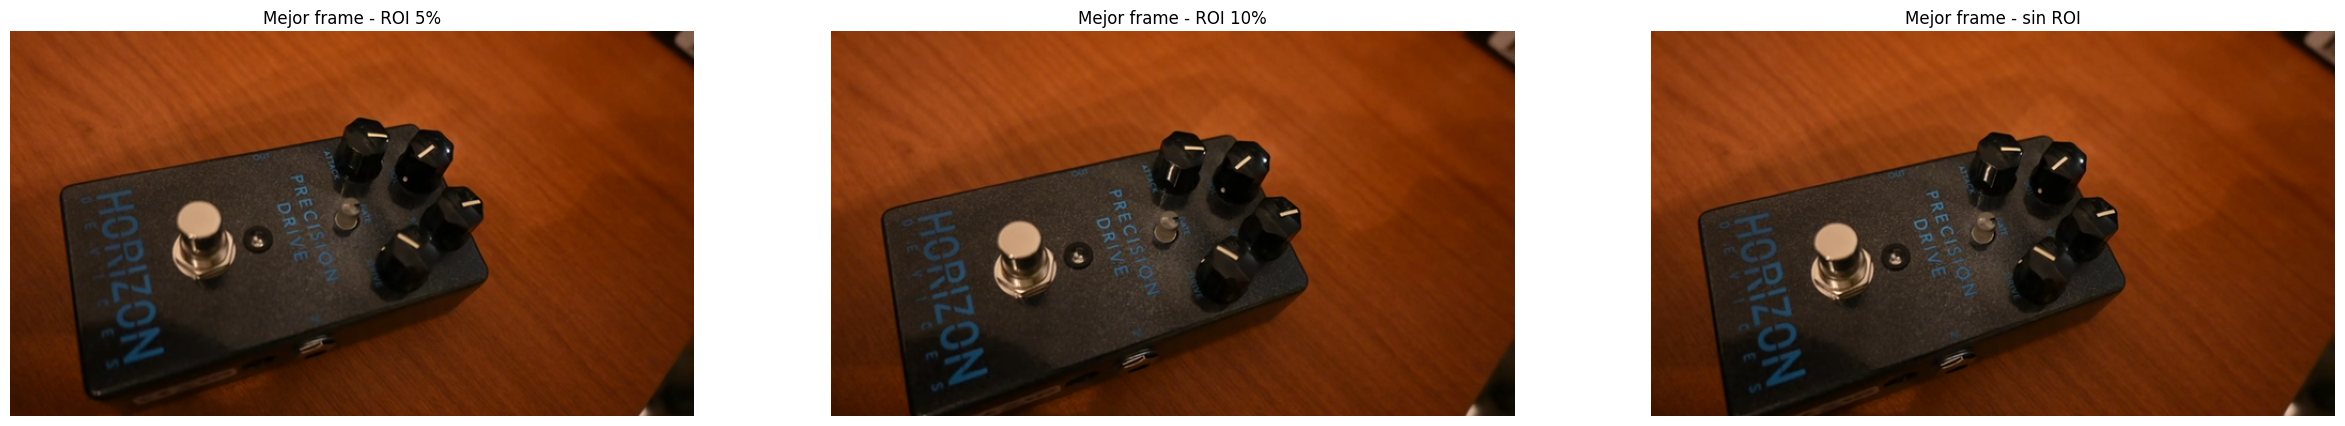

In [192]:
sv.plot_images_grid(
        images=[ms_roi_5_frame, ms_roi_10_frame, ms_roi_100_frame],
        titles=['Mejor frame - ROI 5%', "Mejor frame - ROI 10%", "Mejor frame - sin ROI"],
        grid_size=(1, 3),
        size=(30,10)
    )

## Punto 2

A continuación se estudiarán tres métricas diferentes para medir el enfoque frame a frame del video `focus_video.mov`.

Por cada métrica se realizarán dos experimentos:

- Uno sin implementar área de interés o *ROI*.
- Uno implementando un áre de interés o *ROI* del $5\%$.

***Métricas a estudiar***

Se estudiarán las siguientes métricas explicadas en el apéndice del paper `Analysis of focus measure operators in shapefrom focus`:

- `Tenengrad Focus Measure` (apéndice `A15`).
- `Brenner Focus Measure` (apéndice `A2`).
- `Variance of Laplacian` (apéndice `A20`).

***Definición de experimentos***

En cuanto a los experimentos, estos se caracterizan por lo siguiente:

1. Se procesará el video `focus_video.mov` frame a frame.
1. Se convertirá el frame *BGR* en *escala de grises*. Esto se debe a lo siguiente:
    1. El método para procesar video mediante *OpenCV* (cv.VideoCapture) devuelve los frames en *BGR* (mas info [aquí](https://docs.opencv.org/4.x/dd/d43/tutorial_py_video_display.html)).
    1. El algoritmo implementa la transformada de *Fourier* y la implementación de *Numpy* (`np.fft.fft2`) requiere la imagen en escala de grises (mas info [aquí](https://docs.opencv.org/4.x/de/dbc/tutorial_py_fourier_transform.html)).
1. Se Aplicará *unsharp masking* para mejorar la nitidez de la imagen (mas info [aquí](https://www.opencvhelp.org/tutorials/image-processing/how-to-sharpen-image/)).
    1. `sigmaX` de $1.0$: corresponde al desvío estandar del kernel gaussiano en *X* y determinará el tamaño del kernel a utilizar (mas info [aquí](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gae8bdcd9154ed5ca3cbc1766d960f45c1)).
    1. `sigmaY`: se utilizará el mismo valor que `sigmaX`, tal como especifica la documentación de [GaussianBlur()](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gae8bdcd9154ed5ca3cbc1766d960f45c1) de *OpenCV*.
    1. `strength`: se configurará con un valor de $3.0$.
1. En algunos experimentos, se calculará un *área de interés* o *ROI* de la imagen a partir de su centro, con un área correspondiente al $5\%$ del área total del frame.
1. Se obtendrá la métrica deseada.
1. Se graficará la evolución de la métrica frame a frame.

| Experimento nro. | Métrica | unsharp masking - `sigmaX` | unsharp masking - `weight` | ROI% |
| --- | --- | --- | --- | --- |
| $01$ | `Tenengrad Focus Measure` | $1.0$ | $3.0$ | No aplica (o ROI de 100%) |
| $02$ | `Tenengrad Focus Measure` | $1.0$ | $3.0$ | ROI $5\%$ |
| $03$ | `Brenner Gradient Focus Measure` | $1.0$ | $3.0$ | No aplica (o ROI de 100%) |
| $04$ | `Brenner Gradient Focus Measure` | $1.0$ | $3.0$ | ROI $5\%$ |
| $05$ | `Variance of Laplacian` | $1.0$ | $3.0$ | No aplica (o ROI de 100%) |
| $06$ | `Variance of Laplacian` | $1.0$ | $3.0$ | ROI $5\%$ |

### Métrica 01 - Tenengrad Focus Measure

***Definición de la métrica***

En esta sección se estudiará la métrica de `Tenengrad Focus Measure`, la cual se define de la siguiente manera:

$$\Theta_{x,y} = \Sigma_{(i, j) \in \Omega(x,y)}(G_{x}(i, j)^{2} + G_{y}(i, j)^{2})$$

Donde $G_{x}$ y $G_{y}$ son los gradientes $X$ y $Y$ computados al convolucionar la imagen $I$ con operadores de *Sobel*.

***Implementación de la métrica***

Esta métrica está implementada en el método `tenengradFocusMeasure` de la clase [ImageQuality](../utilities/image_quality.py).

#### Tenengrad Focus Measure - Con Unsharp Masking - Sin ROI

En esta sección se estudió la métrica de `Tenengrad`, utilizando *unsharp masking* pero sin utilizar *ROI*.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $01$ | `Tenengrad focus measure` | $1.0$ | $3.0$ | - | $111$ | $42.7908$ | $4.9$ segundos. |

In [52]:
tenengrad_df, tenengrad_max_frame, tenengrad_max_measure, tenengrad_frame, tenengrad_gray_frame = obtener_métricas_de_video(path=video_path, roiPercentage=1.0, unsharpMasking=unsharpMasking, measure=QualityMeasure.TENENGRAD_FOCUS_MEASURE)

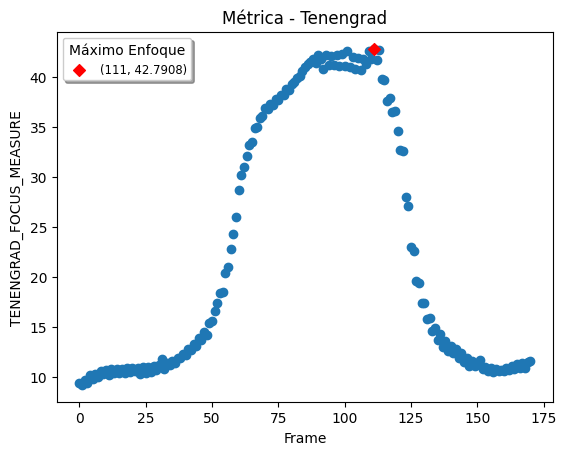

In [53]:
graficar_metricas_por_frames(tenengrad_df, x=tenengrad_max_frame, y=tenengrad_max_measure, title="Métrica - Tenengrad")

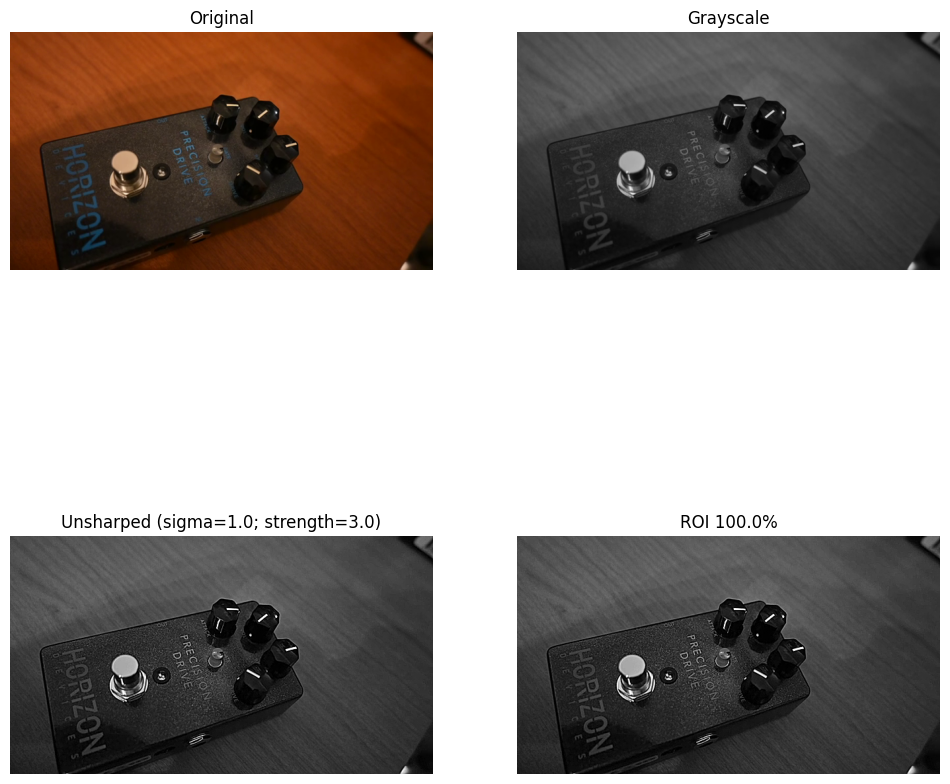

In [54]:
graficar_imagenes_utilizadas(tenengrad_frame, tenengrad_gray_frame, roiPercentage=1.0, unsharpMasking=unsharpMasking)

#### Tenengrad Focus Measure- Con Unsharp Masking - Con ROI 5%

En esta sección se estudió la métrica de `Tenengrad`, utilizando *unsharp masking* con *ROI* de $5\%$.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $01$ | `Tenengrad focus measure` | $1.0$ | $3.0$ | - | $111$ | $42.7908$ | $4.9$ segundos. |
| $02$ | `Tenengrad focus measure` | $1.0$ | $3.0$ | $5\%$ | $111$ | $175.5407$ | $1.4$ segundos. |

In [55]:
tenengrad_05_df, tenengrad_05_max_frame, tenengrad_05_max_measure, tenengrad_05_frame, tenengrad_05_gray_frame = obtener_métricas_de_video(path=video_path, roiPercentage=0.05, unsharpMasking=unsharpMasking, measure=QualityMeasure.TENENGRAD_FOCUS_MEASURE)

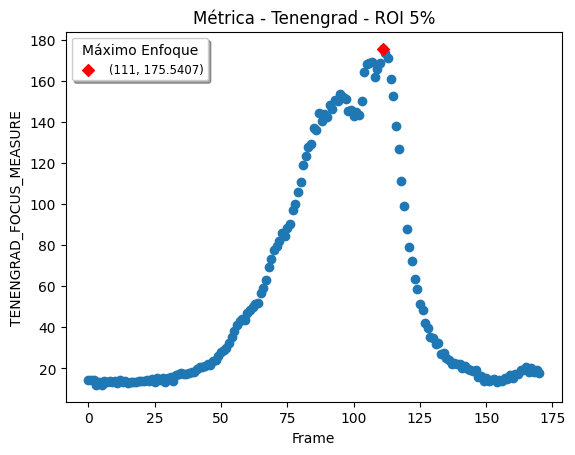

In [56]:
graficar_metricas_por_frames(tenengrad_05_df, x=tenengrad_05_max_frame, y=tenengrad_05_max_measure, title="Métrica - Tenengrad - ROI 5%")

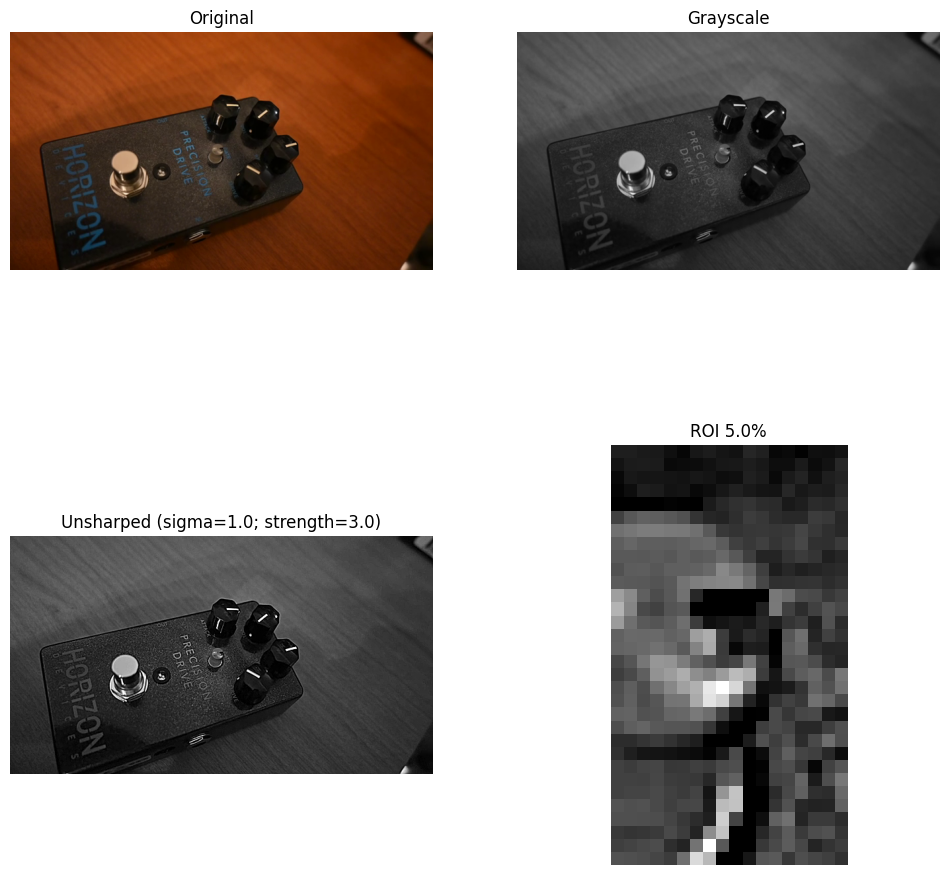

In [57]:
graficar_imagenes_utilizadas(tenengrad_05_frame, tenengrad_05_gray_frame, roiPercentage=0.05, unsharpMasking=unsharpMasking)

#### Tenengrad Focus Measure - Comparación de Frames con mejores métricas

Estos son los resultados obtenidos al aplicar la métrica de `Tenengrad` frame a frame sobre el video de estudio.

Como se puede observar, en abmos experimentos se obtuvo como punto de máximo enfoque en el frame $111$.

La diferencia radica que el experimento $2$ (que utiliza un *ROI* del $5\%$) obtuvo mejor valor de métrica, como así también se ejecutó en menos tiempo.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $01$ | `Tenengrad focus measure` | $1.0$ | $3.0$ | - | $111$ | $42.7908$ | $4.9$ segundos. |
| $02$ | `Tenengrad focus measure` | $1.0$ | $3.0$ | $5\%$ | $111$ | $175.5407$ | $1.4$ segundos. |

A continucación se muestran los frames donde se obtuvieron las mejores métricas en cada experimento.

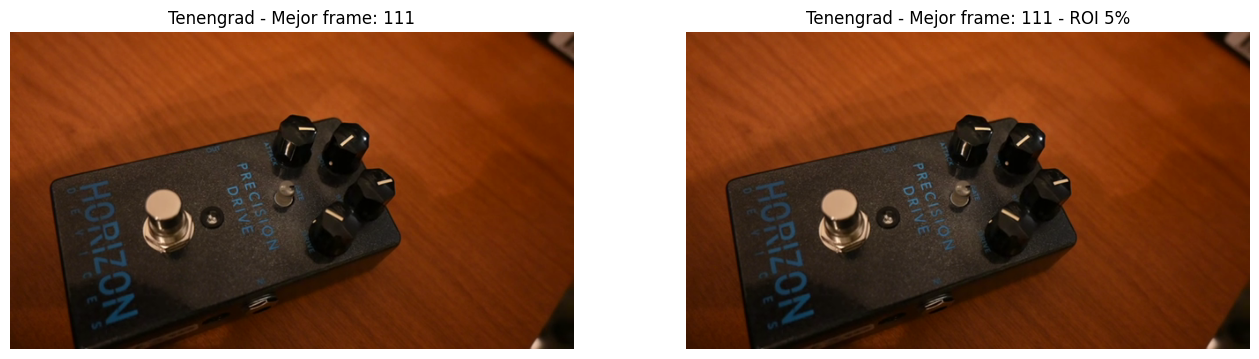

In [74]:
sv.plot_images_grid(
    images=[tenengrad_frame, tenengrad_05_frame],
    titles=[f"Tenengrad - Mejor frame: {int(tenengrad_max_frame)}", f"Tenengrad - Mejor frame: {int(tenengrad_05_max_frame)} - ROI 5%"],
    grid_size=(1, 2),
    size=(16,6)
)

A continuación se comparan la evolución de la métrica de `Tenengrad` frame a frame para los casos de estudio:

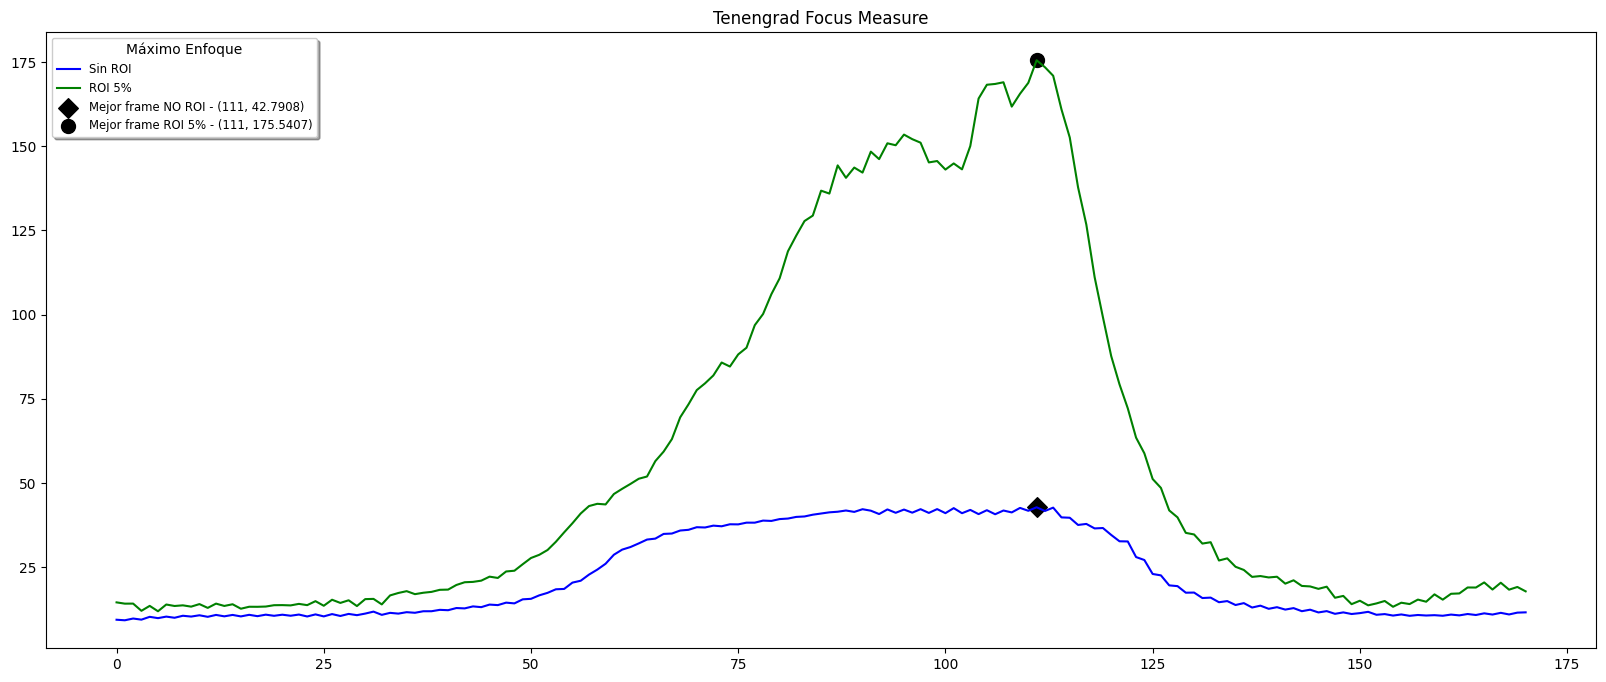

In [75]:
plt.figure(figsize=(20, 8))
plt.plot(tenengrad_df.iloc[:,0], tenengrad_df.iloc[:,1], c="blue", label=f"Sin ROI")
plt.plot(tenengrad_05_df.iloc[:,0], tenengrad_05_df.iloc[:,1], c="green", label=f"ROI 5%")

plt.scatter(tenengrad_max_frame, tenengrad_max_measure, c="black", marker="D", s=100, label=f"Mejor frame NO ROI - {(int(tenengrad_max_frame), float(np.round(tenengrad_max_measure, 4)))}")
plt.scatter(tenengrad_05_max_frame, tenengrad_05_max_measure, c="black", marker="o", s=100, label=f"Mejor frame ROI 5% - {(int(tenengrad_05_max_frame), float(np.round(tenengrad_05_max_measure, 4)))}")

plt.title("Tenengrad Focus Measure")
plt.legend(loc='upper left', title="Máximo Enfoque", ncol=1, fontsize='small', frameon=True, shadow=True)

### Métrica 02 - Brenner Gradient Focus Measure

***Definición de la métrica***

En esta sección se estudiará la métrica de `Brenner Gradient Focus Measure`, la cual se define de la siguiente manera:

$$\Theta = \Sigma_{(i, j)}|I(i, j) -I(i+2, j)|^{2}$$

Donde $G_{x}$ y $G_{y}$ son los gradientes $X$ y $Y$ computados al convolucionar la imagen $I$ con operadores de *Sobel*.

***Implementación de la métrica***

Esta métrica está implementada en el método `brennerGradientFocusMeasure` de la clase [ImageQuality](../utilities/image_quality.py).

#### Brenner Gradient Focus Measure - Con Unsharp Masking - Sin ROI

En esta sección se estudió la métrica de `Brenner Gradiente`, utilizando *unsharp masking* pero sin utilizar *ROI*.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $03$ | `Brenner Gradiente focus measure` | $1.0$ | $3.0$ | - | $72$ | $11208034$ | $3.2$ segundos. |

Al graficar la evolución de la métrica frame a frame se observa la particularidad de que presenta un *valle* entre los frames $72$ (máximo enfoque) y $120$ (aprox).

In [59]:
brenner_df, brenner_max_frame, brenner_max_measure, brenner_frame, brenner_gray_frame = obtener_métricas_de_video(path=video_path, roiPercentage=1.0, unsharpMasking=unsharpMasking, measure=QualityMeasure.BRENNER_GRADIENT_FOCUS_MEASURE)

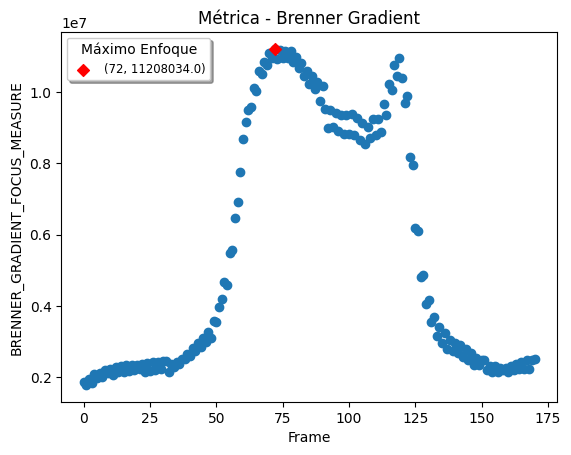

In [60]:
graficar_metricas_por_frames(brenner_df, x=brenner_max_frame, y=brenner_max_measure, title="Métrica - Brenner Gradient")

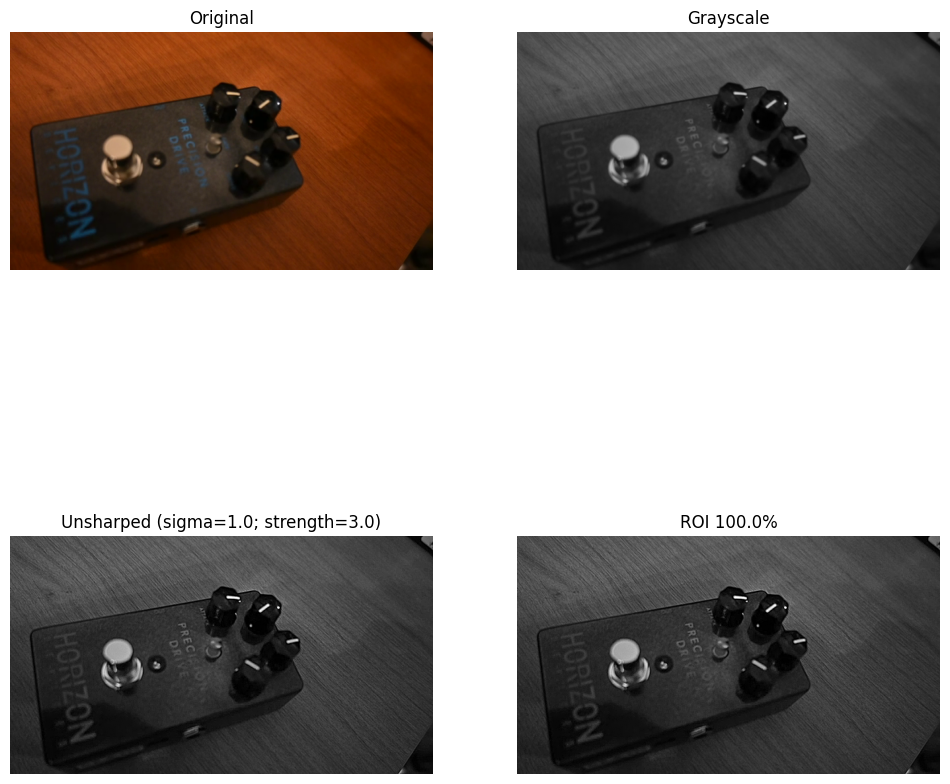

In [61]:
graficar_imagenes_utilizadas(brenner_frame, brenner_gray_frame, roiPercentage=1.0, unsharpMasking=unsharpMasking)

#### Brenner Gradient Focus Measure - Con Unsharp Masking - Con ROI 5%

En esta sección se estudió la métrica de `Brenner Gradiente`, utilizando *unsharp masking* con *ROI* del $5\%$.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $03$ | `Brenner Gradiente focus measure` | $1.0$ | $3.0$ | - | $72$ | $11208034$ | $3.2$ segundos. |
| $04$ | `Brenner Gradiente focus measure` | $1.0$ | $3.0$ | $5\%$ | $109$ | $55468$ | $1.9$ segundos. |

In [62]:
brenner_05_df, brenner_05_max_frame, brenner_05_max_measure, brenner_05_frame, brenner_05_gray_frame = obtener_métricas_de_video(path=video_path, roiPercentage=0.05, unsharpMasking=unsharpMasking, measure=QualityMeasure.BRENNER_GRADIENT_FOCUS_MEASURE)

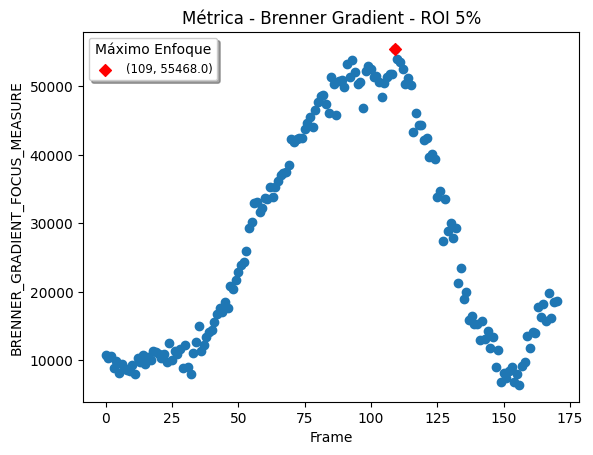

In [63]:
graficar_metricas_por_frames(brenner_05_df, x=brenner_05_max_frame, y=brenner_05_max_measure, title="Métrica - Brenner Gradient - ROI 5%")

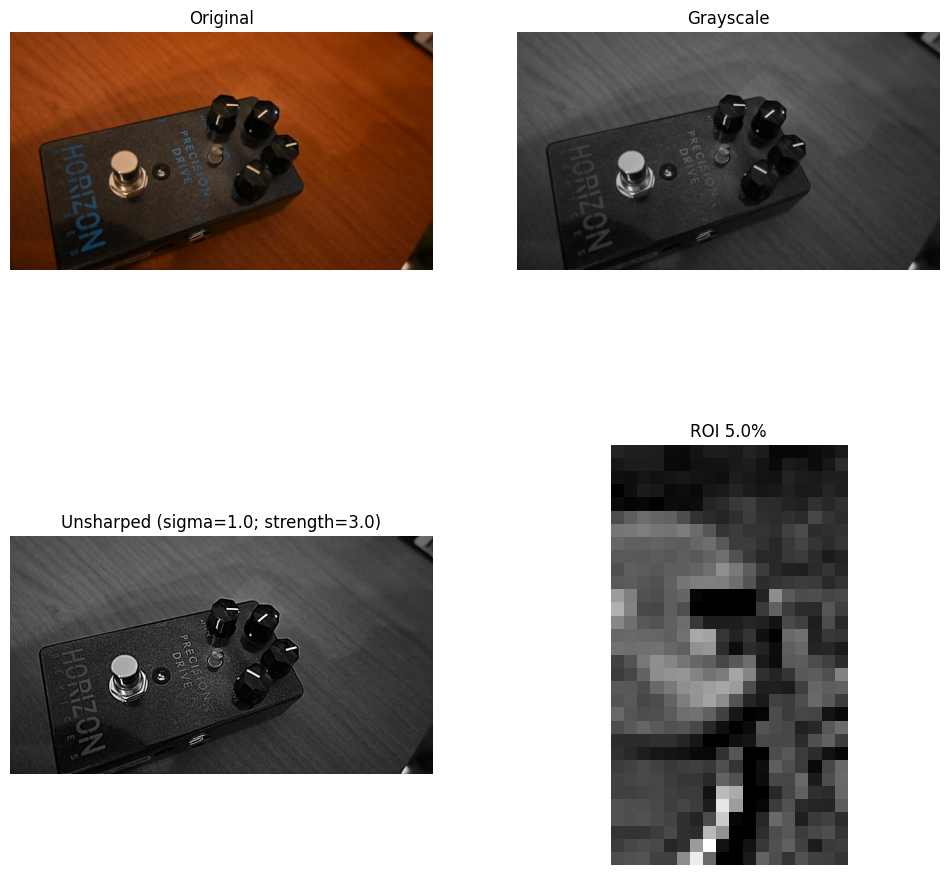

In [64]:
graficar_imagenes_utilizadas(brenner_05_frame, brenner_05_gray_frame, roiPercentage=0.05, unsharpMasking=unsharpMasking)

#### Brenner Gradient Focus Measure - Comparación de Frames con mejores métricas

Estos son los resultados obtenidos al aplicar la métrica de `Brenner Gradient` frame a frame sobre el video de estudio.

El punto de máximo enfoque en el experimento $03$ fue en el frame $72$, mientras que en el experimento $04$ fue en el frame $109$.

Al graficar ambos frames, se observa que el frame del experimento $04$ es más nítido que el frame del experimento $03$.

A diferencia de otros casos de estudio, aquí sucede que el experimento sin *ROI* obtiene mejor métrica que el experimento con *ROI* de $5\%$. Igualmente, esto no parece indicar que las imágenes sean más nitidas, ya que al visualizar los puntos de máximo enfoque el mejor resulta ser aquel con menor métrica.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $03$ | `Brenner Gradiente focus measure` | $1.0$ | $3.0$ | - | $72$ | $11208034$ | $3.2$ segundos. |
| $04$ | `Brenner Gradiente focus measure` | $1.0$ | $3.0$ | $5\%$ | $109$ | $55468$ | $1.9$ segundos. |

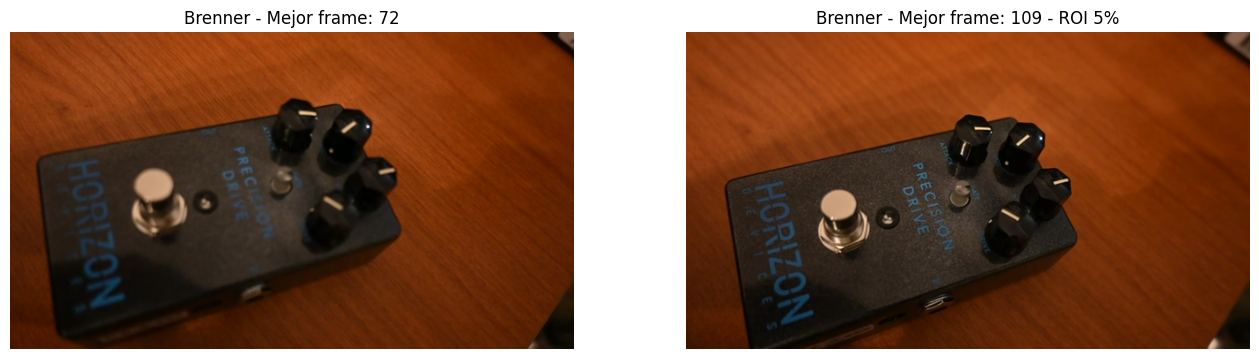

In [76]:
sv.plot_images_grid(
    images=[brenner_frame, brenner_05_frame],
    titles=[f"Brenner - Mejor frame: {brenner_max_frame}", f"Brenner - Mejor frame: {brenner_05_max_frame} - ROI 5%"],
    grid_size=(1, 2),
    size=(16,6)
)

A continuación se comparan la evolución de la métrica de `Brenner Gradient` frame a frame para los casos de estudio:

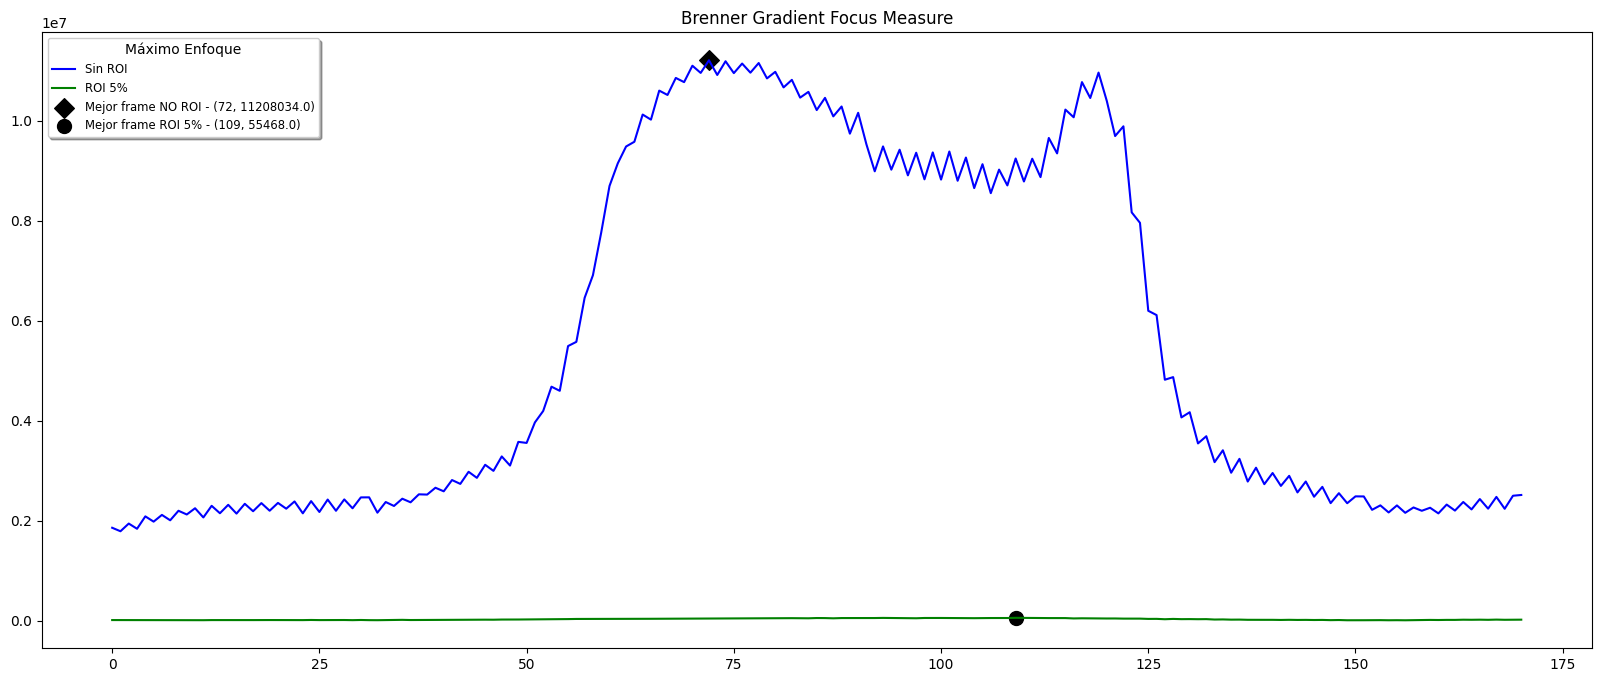

In [77]:
plt.figure(figsize=(20, 8))
plt.plot(brenner_df.iloc[:,0], brenner_df.iloc[:,1], c="blue", label=f"Sin ROI")
plt.plot(brenner_05_df.iloc[:,0], brenner_05_df.iloc[:,1], c="green", label=f"ROI 5%")

plt.scatter(brenner_max_frame, brenner_max_measure, c="black", marker="D", s=100, label=f"Mejor frame NO ROI - {(int(brenner_max_frame), float(np.round(brenner_max_measure, 4)))}")
plt.scatter(brenner_05_max_frame, brenner_05_max_measure, c="black", marker="o", s=100, label=f"Mejor frame ROI 5% - {(int(brenner_05_max_frame), float(np.round(brenner_05_max_measure, 4)))}")

plt.title("Brenner Gradient Focus Measure")
plt.legend(loc='upper left', title="Máximo Enfoque", ncol=1, fontsize='small', frameon=True, shadow=True)

### Métrica 03 - Variance of Laplacian

***Definición de la métrica***

En esta sección se estudiará la métrica de `Brenner Gradient Focus Measure`, la cual se define de la siguiente manera:

$$\Theta = \Sigma_{(i, j) \in \Omega(x, y)}(\Delta I(i, j) - \bar{\Delta I})^{2}$$

Donde $\bar{\Delta I}$ es la media de la imagen Laplaciana en $\Omega(x, y)$.

***Implementación de la métrica***

Esta métrica está implementada en el método `varianceOfLaplacianFocusMeasure` de la clase [ImageQuality](../utilities/image_quality.py).

#### Variance of Laplacian - Con Unsharp Masking - Sin ROI

En esta sección se estudió la métrica de `Variance of Laplacian`, utilizando *unsharp masking* pero sin utilizar *ROI*.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $05$ | `Variance of Laplacian` | $1.0$ | $3.0$ | - | $111$ | $1003.79$ | $2.8$ segundos. |

In [66]:
vol_df, vol_max_frame, vol_max_measure, vol_frame, vol_gray_frame = obtener_métricas_de_video(path=video_path, roiPercentage=1.0, unsharpMasking=unsharpMasking, measure=QualityMeasure.VARIANCE_OF_LAPLACIAN_FOCUS_MEASURE)

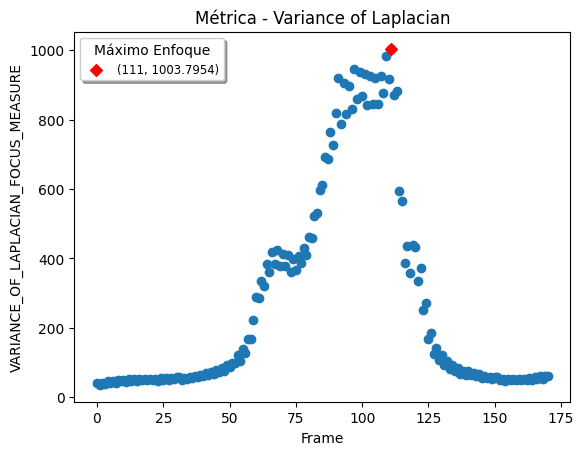

In [67]:
graficar_metricas_por_frames(vol_df, x=vol_max_frame, y=vol_max_measure, title="Métrica - Variance of Laplacian")

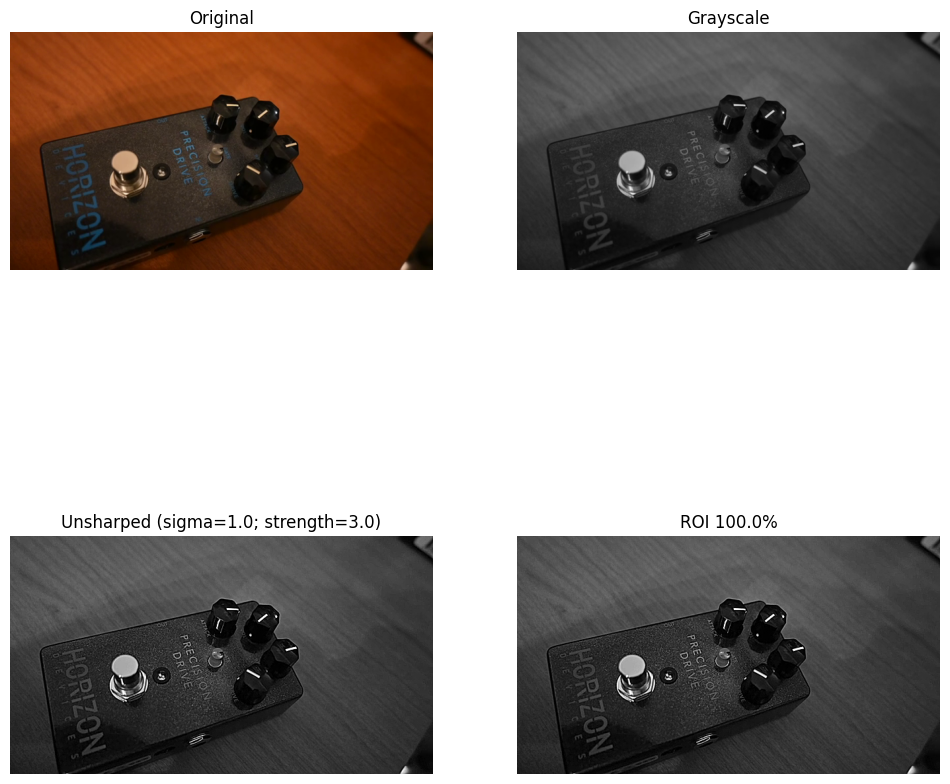

In [68]:
graficar_imagenes_utilizadas(vol_frame, vol_gray_frame, roiPercentage=1.0, unsharpMasking=unsharpMasking)

#### Variance of Laplacian - Con Unsharp Masking - Con ROI 5%

En esta sección se estudió la métrica de `Variance of Laplacian`, utilizando *unsharp masking* con *ROI* del $5\%$.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $05$ | `Variance of Laplacian` | $1.0$ | $3.0$ | - | $111$ | $1003.79$ | $2.8$ segundos. |
| $06$ | `Variance of Laplacian` | $1.0$ | $3.0$ | $5\%$ | $103$ | $9455.68$ | $1.1$ segundos. |

In [69]:
vol_05_df, vol_05_max_frame, vol_05_max_measure, vol_05_frame, vol_05_gray_frame = obtener_métricas_de_video(path=video_path, roiPercentage=0.05, unsharpMasking=unsharpMasking, measure=QualityMeasure.VARIANCE_OF_LAPLACIAN_FOCUS_MEASURE)

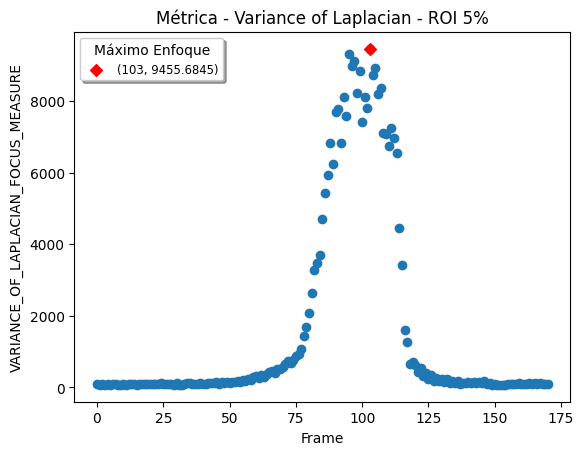

In [70]:
graficar_metricas_por_frames(vol_05_df, x=vol_05_max_frame, y=vol_05_max_measure, title="Métrica - Variance of Laplacian - ROI 5%")

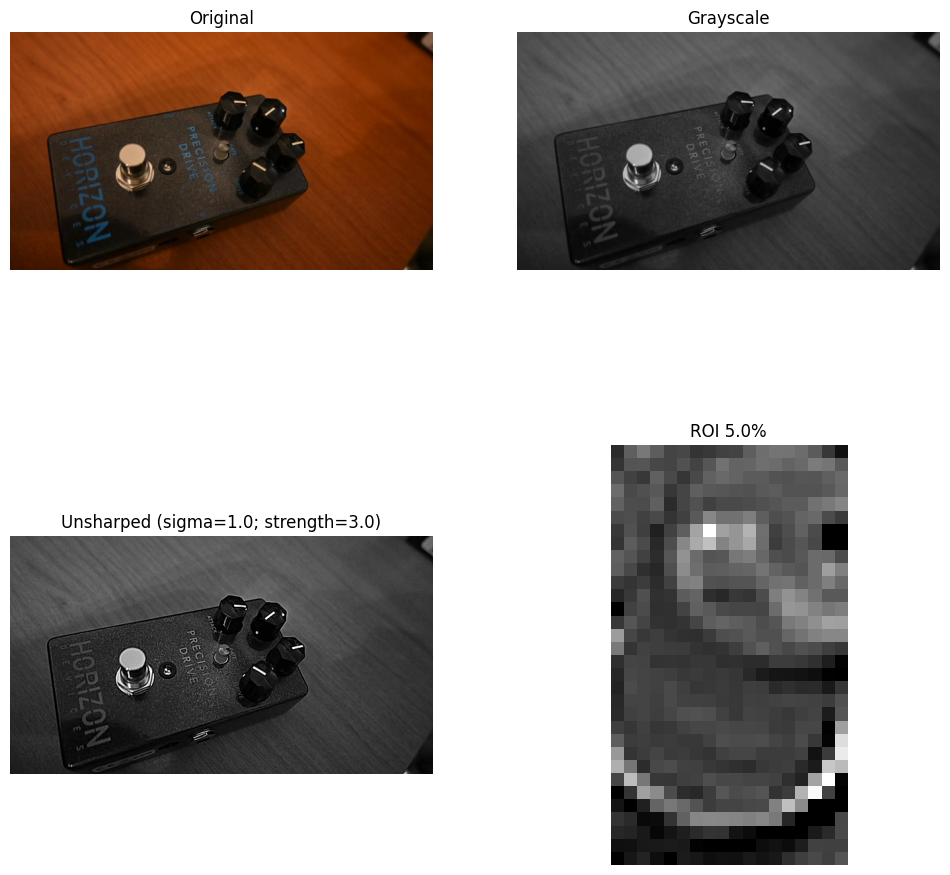

In [71]:
graficar_imagenes_utilizadas(vol_05_frame, vol_05_gray_frame, roiPercentage=0.05, unsharpMasking=unsharpMasking)

#### Variance of Laplacian - Comparación de Frames con mejores métricas

Estos son los resultados obtenidos al aplicar la métrica de `Variance of Laplacian` frame a frame sobre el video de estudio.

El punto de máximo enfoque en el experimento $05$ fue en el frame $111$, mientras que en el experimento $06$ fue en el frame $103$.

Al graficar la evolución de las métricas frame a frame se observa que ambos experimentos tienen valores cercanos en los frames correspondientes al comienzo y al final del video, es decir, en las secciones donde la cámara está desenfocada. Pero en el resto de los frames, correspondientes a cuando la cámara se enfoca, el experimento $06$ (con *ROI* del $5\%$) tiene valores mayores que el otro experimento.

Esto puede deberse a que en el área reducida al $5\%$ del frame el algoritmo detecte mayor varianza que la detectada en la totalidad del frame, lo cual permite obtener una mejor métrica.

Además, el experimento que utiliza *ROI* tarda menos en ejecutarse.

| Experimento Nro | Métrica | *unsharp Masking* `sigmaX` | *unsharp Masking* `strength` | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| ---| --- | --- | --- | --- | --- | --- | --- |
| $05$ | `Variance of Laplacian` | $1.0$ | $3.0$ | - | $111$ | $1003.79$ | $2.8$ segundos. |
| $06$ | `Variance of Laplacian` | $1.0$ | $3.0$ | $5\%$ | $103$ | $9455.68$ | $1.1$ segundos. |

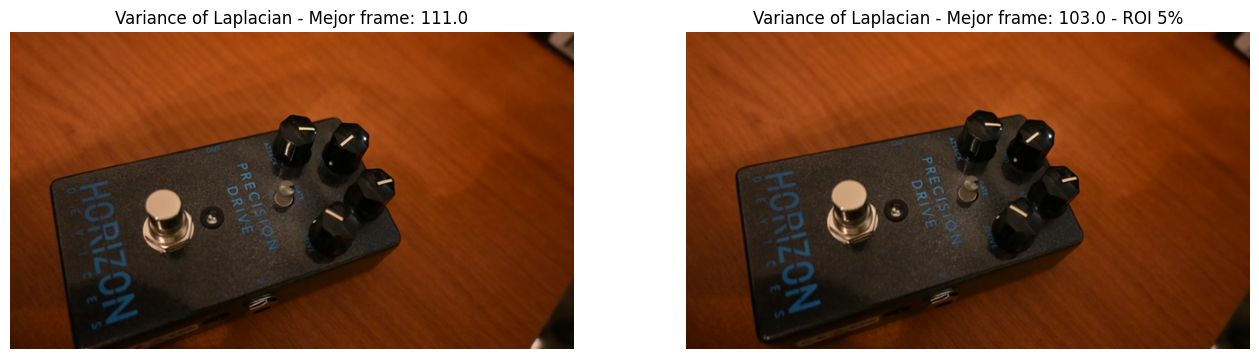

In [78]:
sv.plot_images_grid(
    images=[vol_frame, vol_05_frame],
    titles=[f"Variance of Laplacian - Mejor frame: {vol_max_frame}", f"Variance of Laplacian - Mejor frame: {vol_05_max_frame} - ROI 5%"],
    grid_size=(1, 2),
    size=(16,6)
)

A continuación se comparan la evolución de la métrica de `Variance of Laplacian` frame a frame para los casos de estudio:

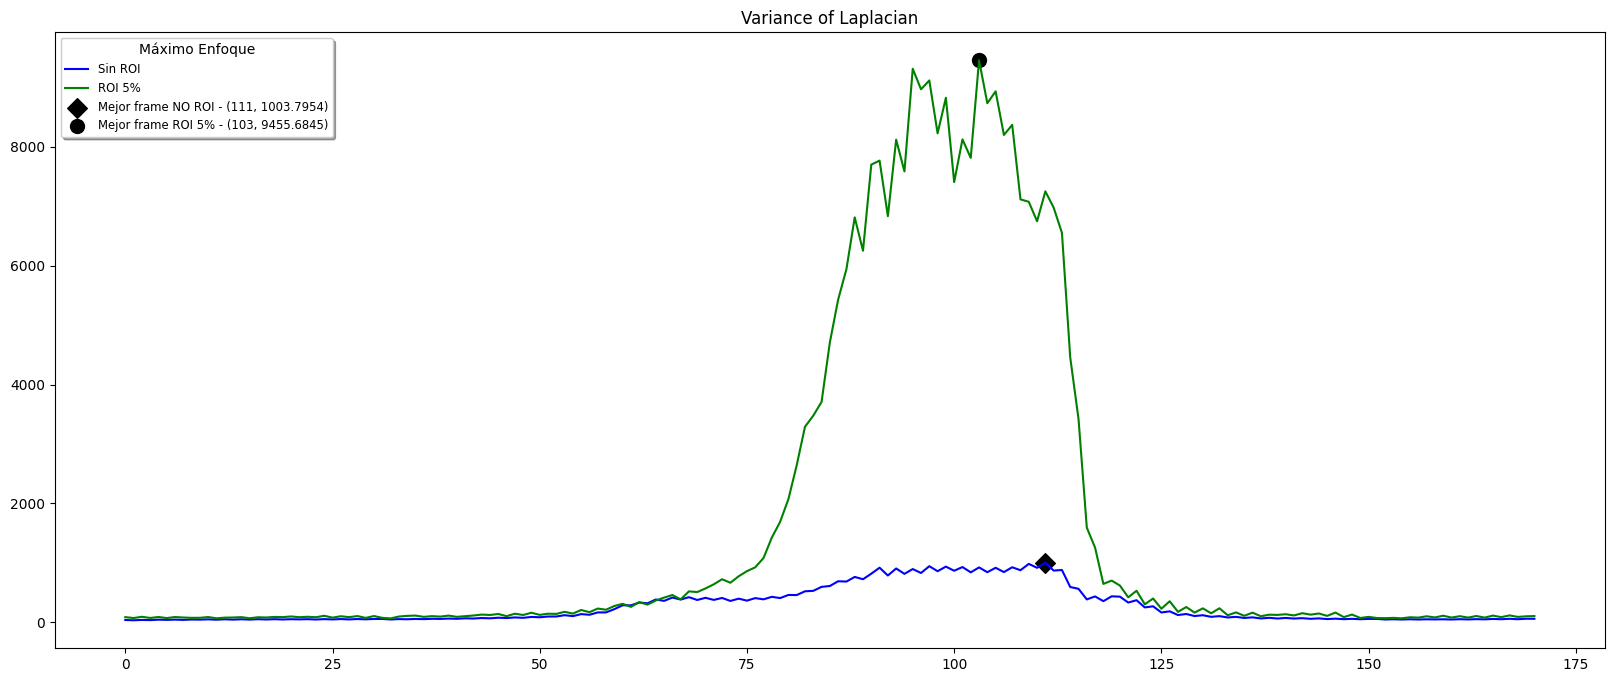

In [79]:
plt.figure(figsize=(20, 8))
plt.plot(vol_df.iloc[:,0], vol_df.iloc[:,1], c="blue", label=f"Sin ROI")
plt.plot(vol_05_df.iloc[:,0], vol_05_df.iloc[:,1], c="green", label=f"ROI 5%")

plt.scatter(vol_max_frame, vol_max_measure, c="black", marker="D", s=100, label=f"Mejor frame NO ROI - {(int(vol_max_frame), float(np.round(vol_max_measure, 4)))}")
plt.scatter(vol_05_max_frame, vol_05_max_measure, c="black", marker="o", s=100, label=f"Mejor frame ROI 5% - {(int(vol_05_max_frame), float(np.round(vol_05_max_measure, 4)))}")

plt.title("Variance of Laplacian")
plt.legend(loc='upper left', title="Máximo Enfoque", ncol=1, fontsize='small', frameon=True, shadow=True)